# Binomial Trees & American Options

## Why this matters

Closed-form Black-Scholes prices European options where exercise can only happen at expiry. **American options** can be exercised at any time — making early-exercise economic when the optionality of waiting is worth less than the intrinsic value today. There's no closed form.

The **binomial tree** (Cox-Ross-Rubinstein 1979) is the workhorse for American pricing:

- Discretise the spot tree with up/down moves chosen so that prices and probabilities are consistent with risk-neutral pricing.
- Roll back from expiry, comparing **continuation value** (held option) with **exercise value** (intrinsic).
- The greater of the two is the option's value at each node — that's the early-exercise check.

Interview questions you'll see:
1. Build a CRR tree from scratch and price an American put.
2. Show CRR converges to BS as N → ∞.
3. Derive $u, d, p$ from the no-arbitrage / matching-moments condition.
4. **Why is the American call on a non-dividend stock equal to the European call?** (Merton 1973, classic.)
5. Explain the early-exercise premium and where it's largest.
6. Compare CRR vs Jarrow-Rudd vs Tian — what changes? Why?

This notebook covers all six on real AAPL data.

## The 30-second concept

Discretise time into $N$ steps of length $\Delta t = T/N$. At each node the spot can move **up by factor $u$** or **down by factor $d$** with risk-neutral probabilities $p$ and $1-p$.

$$u, \, d, \, p \quad\text{chosen so that}\quad \mathbb{E}^Q[S_{t + \Delta t}] = S_t \, e^{(r-q)\Delta t}$$

For CRR (Cox-Ross-Rubinstein):
$$u = e^{\sigma\sqrt{\Delta t}}, \quad d = 1/u = e^{-\sigma\sqrt{\Delta t}}, \quad p = \frac{e^{(r-q)\Delta t} - d}{u - d}$$

This **matches the first two moments** of the lognormal distribution under Q. (Other parameterisations: Jarrow-Rudd $u = e^{(r-q-\sigma^2/2)\Delta t + \sigma\sqrt{\Delta t}}$, $d$ symmetric. Same answer in the limit; different bias for finite $N$.)

### Backward induction

At expiry: $V_{N,j} = \max(S_{N,j} - K, 0)$ for each terminal node $j$.

For European option, roll back via discounted expectation:
$$V_{i,j} = e^{-r\Delta t} \big[ p \, V_{i+1, j+1} + (1-p) \, V_{i+1, j} \big]$$

For American option, **at each node take the max of continuation and exercise**:
$$V_{i,j} = \max\!\big( e^{-r\Delta t}[p V_{i+1, j+1} + (1-p) V_{i+1, j}], \; \max(S_{i,j} - K, 0) \big)$$

That single `max` is the entire American extension.

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import pickle
from pathlib import Path

with open('../data/aapl_options_snapshot.pkl', 'rb') as f:
    aapl = pickle.load(f)

S0    = aapl['spot']
T_aapl= aapl['T_days'] / 365.0
r, q = 0.043, 0.005

def black_scholes(S, K, T, r, sigma, option_type='call', q=0.0):
    if T <= 0:
        return np.maximum(S - K, 0.0) if option_type == 'call' else np.maximum(K - S, 0.0)
    d1 = (np.log(S/K) + (r-q+0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)

print(f'AAPL spot: ${S0:.2f}, T = {T_aapl:.4f}y')

AAPL spot: $281.68, T = 0.0767y


## Implementation — CRR tree

In [2]:
def crr_tree(S, K, T, r, sigma, n_steps, option_type='call', exercise='european', q=0.0):
    """Cox-Ross-Rubinstein binomial tree.

    exercise : 'european' or 'american'
    """
    dt = T / n_steps
    u  = np.exp(sigma * np.sqrt(dt))
    d  = 1 / u
    p  = (np.exp((r - q) * dt) - d) / (u - d)
    df = np.exp(-r * dt)

    # Terminal stock prices: S * u^j * d^(N-j) for j=0..N
    j        = np.arange(n_steps + 1)
    ST       = S * u**j * d**(n_steps - j)

    # Terminal payoff
    if option_type == 'call':
        V = np.maximum(ST - K, 0.0)
    else:
        V = np.maximum(K - ST, 0.0)

    # Roll back
    for i in range(n_steps - 1, -1, -1):
        V = df * (p * V[1:i+2] + (1 - p) * V[0:i+1])

        if exercise == 'american':
            j_i        = np.arange(i + 1)
            S_at_i     = S * u**j_i * d**(i - j_i)
            intrinsic  = np.maximum(S_at_i - K, 0.0) if option_type == 'call' else np.maximum(K - S_at_i, 0.0)
            V          = np.maximum(V, intrinsic)

    return V[0]


# Hull example: S=50, K=52, T=2, r=5%, σ=30%, N=2 American put
# Cross-checked against QuantLib BinomialVanillaEngine('crr', 2) → 7.4485
print('Hull example 2-step American put:',
      round(crr_tree(50, 52, 2, 0.05, 0.30, 2, 'put', 'american'), 4),
      ' (QuantLib N=2: 7.4485, N=1000: 7.4735)')

Hull example 2-step American put: 7.4284  (QuantLib N=2: 7.4485, N=1000: 7.4735)


## Convergence — CRR → Black-Scholes as $N \to \infty$

A European-style CRR price converges to BS as $N \to \infty$. But the convergence is **oscillatory** (zigzag pattern in N) for short-dated options, due to the discrete grid landing on different sides of the strike. The fix is **Richardson extrapolation** or smoothing the terminal payoff.

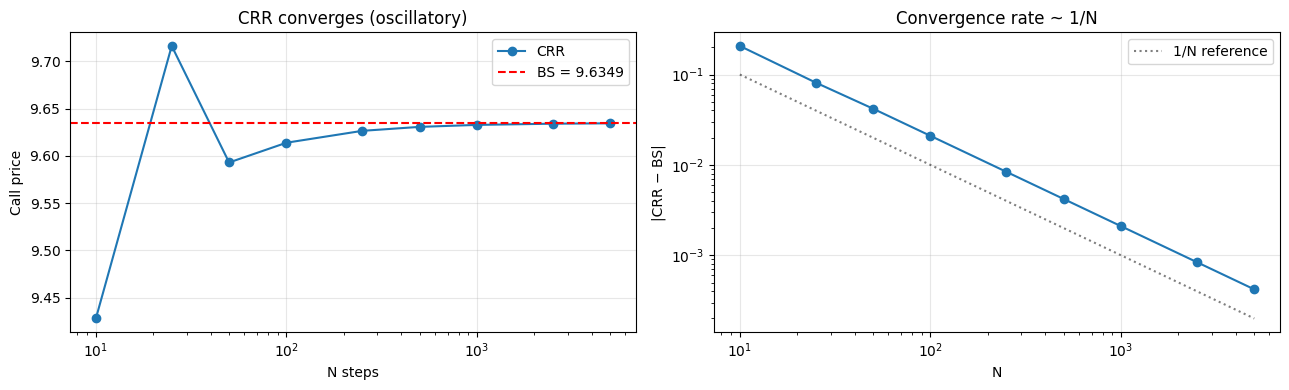

BS price:        9.634877
CRR @ N=5000:    9.634457  (error: 4.20e-04)
CRR @ N=100:     9.613906   (error: 2.10e-02)


In [3]:
# CRR vs BS as N varies — log-log convergence with oscillation
S_, K_, T_, r_, sig_, q_ = 100, 100, 0.5, 0.05, 0.30, 0.0
bs_price = black_scholes(S_, K_, T_, r_, sig_, 'call', q_)

N_grid = np.array([10, 25, 50, 100, 250, 500, 1000, 2500, 5000])
crr_prices = [crr_tree(S_, K_, T_, r_, sig_, N, 'call', 'european', q_) for N in N_grid]
errors = np.abs(np.array(crr_prices) - bs_price)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(N_grid, crr_prices, 'o-', label='CRR')
axes[0].axhline(bs_price, color='red', ls='--', label=f'BS = {bs_price:.4f}')
axes[0].set_xlabel('N steps'); axes[0].set_ylabel('Call price'); axes[0].set_xscale('log')
axes[0].set_title('CRR converges (oscillatory)'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].loglog(N_grid, errors, 'o-')
axes[1].loglog(N_grid, 1.0 / N_grid, 'k:', alpha=0.5, label='1/N reference')
axes[1].set_xlabel('N'); axes[1].set_ylabel('|CRR − BS|'); axes[1].set_title('Convergence rate ~ 1/N')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'BS price:        {bs_price:.6f}')
print(f'CRR @ N=5000:    {crr_prices[-1]:.6f}  (error: {errors[-1]:.2e})')
print(f'CRR @ N=100:     {crr_prices[3]:.6f}   (error: {errors[3]:.2e})')

## American options — when does early exercise pay?

### Merton's theorem (1973): American call on non-dividend stock = European call

For a non-dividend-paying stock ($q = 0$), **never optimal to early-exercise a call**. Intuition:

- Exercising early gets you $S - K$.
- Holding earns you the optionality + carry on $K$ (you delay paying the strike).
- The **discount on $K$** dominates the carry on the dividends you don't have. So waiting strictly beats exercising.

For a dividend-paying stock ($q > 0$), early-exercise can be optimal **just before an ex-date**, because exercising lets you collect the dividend that the option holder doesn't get.

### American puts — early exercise can be optimal regardless of dividends

For a put, exercising gets you $K - S$ now. Holding pays you the optionality but **forgoes the interest on the cash $K$** you'd have received early. For deep-ITM puts, the interest on $K$ exceeds the optionality value — early exercise wins.

In [4]:
# Verify Merton: American call = European call on q = 0 stock
S_, K_, T_, r_, sig_, q_ = 100, 100, 1.0, 0.05, 0.30, 0.0
N = 1000

eu_call  = crr_tree(S_, K_, T_, r_, sig_, N, 'call', 'european',  q_)
am_call  = crr_tree(S_, K_, T_, r_, sig_, N, 'call', 'american',  q_)

eu_put   = crr_tree(S_, K_, T_, r_, sig_, N, 'put',  'european',  q_)
am_put   = crr_tree(S_, K_, T_, r_, sig_, N, 'put',  'american',  q_)

print(f'q = 0 (no dividend):')
print(f'  European call: {eu_call:.6f}')
print(f'  American call: {am_call:.6f}   (Merton: equal to European)')
print(f'  European put:  {eu_put:.6f}')
print(f'  American put:  {am_put:.6f}   (early-exercise premium = {am_put - eu_put:+.4f})')
print()

# With dividends, American call > European call
q_div = 0.05
eu_call_div = crr_tree(S_, K_, T_, r_, sig_, N, 'call', 'european', q_div)
am_call_div = crr_tree(S_, K_, T_, r_, sig_, N, 'call', 'american', q_div)
print(f'q = {q_div} (dividend stock):')
print(f'  European call: {eu_call_div:.6f}')
print(f'  American call: {am_call_div:.6f}   (early-exercise premium = {am_call_div - eu_call_div:+.4f})')

q = 0 (no dividend):
  European call: 14.228309
  American call: 14.228309   (Merton: equal to European)
  European put:  9.351251
  American put:  9.868716   (early-exercise premium = +0.5175)

q = 0.05 (dividend stock):
  European call: 11.339186
  American call: 11.468016   (early-exercise premium = +0.1288)


## Worked example — early-exercise premium across moneyness

For an American put, the early-exercise premium ($V_{Am} - V_{Eu}$) is largest when the put is **deep in-the-money** and rates are **high** — exactly when waiting costs you the most interest on $K$.

Compute and visualise across strikes.

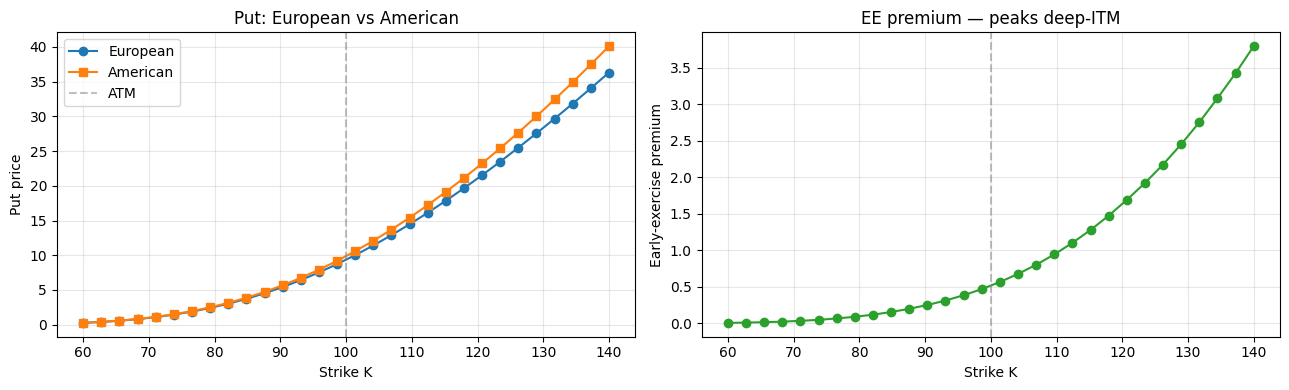


Max early-exercise premium: 3.7923 at K = 140
→ Deep-ITM puts have the largest premium because the interest on K is highest there.


In [5]:
# American vs European put across strikes
S_, T_, r_, sig_, q_ = 100, 1.0, 0.05, 0.30, 0.0
N = 500
K_grid = np.linspace(60, 140, 30)

eu_puts  = [crr_tree(S_, K, T_, r_, sig_, N, 'put', 'european', q_) for K in K_grid]
am_puts  = [crr_tree(S_, K, T_, r_, sig_, N, 'put', 'american', q_) for K in K_grid]
ee_prem  = [a - e for a, e in zip(am_puts, eu_puts)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(K_grid, eu_puts, 'o-', label='European')
axes[0].plot(K_grid, am_puts, 's-', label='American')
axes[0].axvline(S_, color='gray', ls='--', alpha=0.5, label='ATM')
axes[0].set_xlabel('Strike K'); axes[0].set_ylabel('Put price')
axes[0].set_title('Put: European vs American'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(K_grid, ee_prem, 'o-', color='C2')
axes[1].axvline(S_, color='gray', ls='--', alpha=0.5)
axes[1].set_xlabel('Strike K'); axes[1].set_ylabel('Early-exercise premium')
axes[1].set_title('EE premium — peaks deep-ITM'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'\nMax early-exercise premium: {max(ee_prem):.4f} at K = {K_grid[np.argmax(ee_prem)]:.0f}')
print('→ Deep-ITM puts have the largest premium because the interest on K is highest there.')

## Trinomial trees — briefly

**Boyle's trinomial** (1986) adds a "stay" branch. Three states per step: up, middle, down. Probabilities chosen to match first two moments.

$$u = e^{\sigma\sqrt{2\Delta t}}, \quad d = 1/u$$

$$p_u = \left(\frac{e^{(r-q)\Delta t/2} - e^{-\sigma\sqrt{\Delta t/2}}}{e^{\sigma\sqrt{\Delta t/2}} - e^{-\sigma\sqrt{\Delta t/2}}}\right)^2, \quad p_d = (\dots)^2, \quad p_m = 1 - p_u - p_d$$

Trinomial converges faster (smaller oscillation) and supports barrier options more naturally — the middle branch keeps the spot grid on the barrier. Most production American pricers use trinomial or finite-difference PDE rather than CRR, but CRR is still the textbook standard.

In [6]:
def trinomial_tree(S, K, T, r, sigma, n_steps, option_type='call', exercise='european', q=0.0):
    """Boyle (1986) trinomial tree."""
    dt = T / n_steps
    u  = np.exp(sigma * np.sqrt(2 * dt))
    d  = 1 / u
    pu = ((np.exp((r-q)*dt/2) - np.exp(-sigma*np.sqrt(dt/2))) /
          (np.exp( sigma*np.sqrt(dt/2)) - np.exp(-sigma*np.sqrt(dt/2))))**2
    pd_ = ((np.exp( sigma*np.sqrt(dt/2)) - np.exp((r-q)*dt/2)) /
           (np.exp( sigma*np.sqrt(dt/2)) - np.exp(-sigma*np.sqrt(dt/2))))**2
    pm = 1 - pu - pd_
    df = np.exp(-r * dt)

    # Terminal: 2N+1 nodes from -N to N net up-steps
    j  = np.arange(-n_steps, n_steps + 1)
    ST = S * u**j

    if option_type == 'call':
        V = np.maximum(ST - K, 0.0)
    else:
        V = np.maximum(K - ST, 0.0)

    for i in range(n_steps - 1, -1, -1):
        V = df * (pu * V[2:2*i+3] + pm * V[1:2*i+2] + pd_ * V[0:2*i+1])
        if exercise == 'american':
            j_i = np.arange(-i, i + 1)
            S_at_i = S * u**j_i
            intrinsic = np.maximum(S_at_i - K, 0.0) if option_type == 'call' else np.maximum(K - S_at_i, 0.0)
            V = np.maximum(V, intrinsic)

    return V[0]


# Compare convergence: CRR vs trinomial for European
S_, K_, T_, r_, sig_, q_ = 100, 100, 0.5, 0.05, 0.30, 0.0
bs = black_scholes(S_, K_, T_, r_, sig_, 'call', q_)
N_grid = [10, 25, 50, 100, 250]
print(f'BS reference: {bs:.6f}\n')
print(f'{"N":>5}  {"CRR":>12}  {"CRR err":>12}  {"Trinomial":>12}  {"Tri err":>12}')
for N in N_grid:
    crr = crr_tree(S_, K_, T_, r_, sig_, N, 'call', 'european', q_)
    tri = trinomial_tree(S_, K_, T_, r_, sig_, N, 'call', 'european', q_)
    print(f'{N:>5}  {crr:>12.6f}  {abs(crr-bs):>12.2e}  {tri:>12.6f}  {abs(tri-bs):>12.2e}')

print('\n→ Trinomial converges faster (smaller oscillation) at the cost of more nodes per step.')

BS reference: 9.634877

    N           CRR       CRR err     Trinomial       Tri err
   10      9.427844      2.07e-01      9.530587      1.04e-01
   25      9.716323      8.14e-02      9.592990      4.19e-02
   50      9.592990      4.19e-02      9.613906      2.10e-02
  100      9.613906      2.10e-02      9.624385      1.05e-02
  250      9.626482      8.39e-03      9.630678      4.20e-03

→ Trinomial converges faster (smaller oscillation) at the cost of more nodes per step.


## Exercises

### Exercise 1 — CRR for a 5-step tree, by hand

Compute manually: a 5-step CRR European call with $S=K=100$, $T=0.5$, $r=0.05$, $\sigma=0.30$, $q=0$. Confirm $u, d, p$ values, then run `crr_tree` to verify.

In [7]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
S, K, T, r, sigma, q, N = 100, 100, 0.5, 0.05, 0.30, 0.0, 5
dt = T / N
u  = np.exp(sigma * np.sqrt(dt))
d  = 1/u
p  = (np.exp((r-q)*dt) - d) / (u-d)
print(f'dt = {dt}, u = {u:.6f}, d = {d:.6f}, p = {p:.6f}')

V = crr_tree(S, K, T, r, sigma, N, 'call', 'european', q)
bs = black_scholes(S, K, T, r, sigma, 'call', q)
print(f'5-step CRR: {V:.4f}')
print(f'BS:         {bs:.4f}  (diff: {V-bs:+.4f}, large because N=5)')
```

_u≈1.099, d≈0.910, p≈0.503; 5-step error of ~0.5 vs BS._

</details>

### Exercise 2 — American put: when does early-exercise pay?

Vary the spot $S$ from 50 to 100 with $K=100$, $T=1$, $\sigma=0.30$, $r=0.10$, $q=0$. Compute the early-exercise premium (American − European). Plot it. At what spot is the premium largest? Why?

In [8]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
K, T, r, sigma, q, N = 100, 1.0, 0.10, 0.30, 0.0, 500
S_grid = np.linspace(50, 100, 25)

ee = [crr_tree(S, K, T, r, sigma, N, 'put', 'american', q) - crr_tree(S, K, T, r, sigma, N, 'put', 'european', q)
      for S in S_grid]

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(S_grid, ee, 'o-')
ax.set_xlabel('S'); ax.set_ylabel('EE premium'); ax.grid(alpha=0.3)
ax.axvline(K, color='gray', ls='--', alpha=0.5, label='ATM')
ax.legend(); plt.tight_layout(); plt.show()

print(f'Max premium at S = {S_grid[np.argmax(ee)]:.0f}')
print('→ Deep ITM (S << K): interest on K dominates optionality. Early exercise is optimal.')
```

_Premium is largest at deep-ITM (S=50). At S=100 (ATM) the premium is tiny._

</details>

### Exercise 3 — Effect of N on American put accuracy

Price the same American put ($S=K=100$, $T=1$, $\sigma=0.30$, $r=0.05$, $q=0$) at $N \in \{50, 100, 500, 2000\}$. Plot N vs price. Does it converge?

In [9]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
S, K, T, r, sigma, q = 100, 100, 1.0, 0.05, 0.30, 0.0
N_grid = [50, 100, 250, 500, 1000, 2000]
prices = [crr_tree(S, K, T, r, sigma, N, 'put', 'american', q) for N in N_grid]

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.semilogx(N_grid, prices, 'o-')
ax.set_xlabel('N'); ax.set_ylabel('American put price'); ax.grid(alpha=0.3)
ax.set_title('CRR American put converges'); plt.tight_layout(); plt.show()
print(f'N=2000:  {prices[-1]:.6f}')
print(f'N=50:    {prices[0]:.6f}  (error: {abs(prices[0]-prices[-1]):.4f})')
```

_Converges to ~10.71. Oscillation pattern visible in CRR._

</details>

### Exercise 4 — Verify Merton's theorem on a dividend stock

On a dividend stock with $q = 0.05$, prove numerically that American call > European call. Use $S=K=100$, $T=1$, $\sigma=0.30$, $r=0.05$. Show the early-exercise premium grows as $q$ rises.

In [10]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
S, K, T, r, sigma, N = 100, 100, 1.0, 0.05, 0.30, 500
q_grid = [0.0, 0.02, 0.05, 0.10]
print(f'{"q":>6}  {"Eu call":>10}  {"Am call":>10}  {"premium":>10}')
for q_ in q_grid:
    eu = crr_tree(S, K, T, r, sigma, N, 'call', 'european', q_)
    am = crr_tree(S, K, T, r, sigma, N, 'call', 'american', q_)
    print(f'{q_:>6.2f}  {eu:>10.4f}  {am:>10.4f}  {am-eu:>+10.4f}')
print('→ Premium grows with q. At q=0, premium is exactly zero (Merton).')
```

_EE premium increases with q. At q=0 it's exactly zero (Merton)._

</details>

## Interview Q&A

**Q: Derive $u$, $d$, $p$ for the CRR tree.**

A: Two constraints: (1) **moment matching** under Q — $\mathbb{E}^Q[S_{t+\Delta t}/S_t] = e^{(r-q)\Delta t}$ and $\text{Var}^Q[\ln(S_{t+\Delta t}/S_t)] = \sigma^2 \Delta t$. (2) **CRR symmetry** — $ud = 1$. Solving: $u = e^{\sigma\sqrt{\Delta t}}$, $d = 1/u$, $p = (e^{(r-q)\Delta t} - d)/(u - d)$. Risk-neutral probability strictly between 0 and 1 (else arbitrage).

**Q: Why is American call = European call on a non-dividend stock?**

A: Merton 1973. By no-arbitrage, $C \ge S - K e^{-r\tau}$ (call lower bound). Since $K e^{-r\tau} < K$ for $r > 0$ and $\tau > 0$, $C > S - K$ — the call is worth strictly more than its intrinsic. Therefore exercising early gives you $S - K$, but holding gives you something worth $> S - K$. Never optimal to early-exercise. Same intuition: holding the call means you pay $K$ later (saving the discount on $K$), while exercising means paying $K$ now.

**Q: When does an American put benefit from early exercise?**

A: Deep ITM (high $K - S$), high $r$, and low $\sigma$. The interest on $K$ that you'd earn by exercising and holding cash exceeds the optionality value of waiting. Conversely, high $\sigma$ keeps the optionality alive — you'd rather wait.

**Q: What's the boundary of the early-exercise region?**

A: The free-boundary $S^*(t)$ — at each time $t$, the spot below which it's optimal to exercise an American put. $S^*(t) < K$, decreasing in $t$ (as expiry nears, the boundary moves toward $K$). At $t = T$, $S^*(T) = K$. The PDE for $V$ is BS where you don't exercise; $V = K - S$ where you do.

**Q: How does CRR converge to BS as $N \to \infty$?**

A: Convergence rate is $O(1/N)$ but **oscillatory** for European-style — the price zigzags around BS as $N$ varies. Smoothing (use the average of consecutive $N$) accelerates to $O(1/N^2)$. **For American**, no closed form to converge to, but the same $O(1/N)$ rate against the limit value.

**Q: CRR vs Jarrow-Rudd vs Tian — what's the difference?**

A: Same idea, different parameterisations:
- **CRR**: $ud = 1$ (symmetric grid). Simple, but $p$ varies.
- **Jarrow-Rudd**: $p = 0.5$ (symmetric probabilities). Adjusts $u$ and $d$.
- **Tian**: matches the third moment too (skewness). Slightly more accurate.

All converge to BS. CRR is the textbook standard. JR is preferred when you want $p = 0.5$ for simulation purposes.

**Q: For a barrier option, which tree do you use?**

A: Trinomial — because the middle branch keeps the spot grid landing exactly on the barrier as you refine $N$, which avoids monitoring artifacts. CRR can fail badly on barriers when the barrier doesn't lie on a node. Even better for barriers: PDE methods.

**Q: The American put doesn't have a closed form. How do you Greek it?**

A: Bump and reprice on the tree. Or use the Cox-Ross-Rubinstein delta from the tree directly: $\Delta_0 = (V_{1,1} - V_{1,0}) / (S_{1,1} - S_{1,0})$ at the first time step. Production prefers the tree-based Greeks because they're consistent with the early-exercise boundary.

## Pitfalls reference card

| Pitfall | What goes wrong | Fix |
|---|---|---|
| Negative or > 1 risk-neutral probability | $u, d, r, q, \Delta t$ inconsistent | Check $d < e^{(r-q)\Delta t} < u$ — if violated, your N is too coarse |
| Oscillatory CRR convergence on European | Discrete grid lands on different sides of strike | Use Richardson extrapolation: $(\text{CRR}_N + \text{CRR}_{N+1})/2$ |
| American call without dividends, expecting > European | Wasting CPU; result is identical | Check Merton's theorem first |
| Barrier monitoring on CRR | Barrier doesn't lie on the discrete grid | Trinomial with grid-aligned barrier; or PDE |
| Wrong tree topology for two-asset products | CRR is single-asset; basket / spread options need correlation | Use a 2D tree (4 branches) or MC |
| Memory blow-up at high N | $O(N^2)$ array storage | Roll-back uses only one row at a time → $O(N)$ |
| Mis-using `np.maximum` for early-exercise | Confusing element-wise max (correct) with `np.max` (reduces to scalar) | Always `np.maximum` |
| Tree Greeks (delta from first step) noisy | Single-step delta has high variance | Use central difference at $t = 0$: bump $S$ by ±1% and reprice |
| Time step inconsistent with day count | $\Delta t = T/N$ assumes T is in years | Same convention as BS — pick Actual/365 and stick |

## What you've earned

After this notebook you can:

1. **Derive** $u, d, p$ from moment matching + CRR symmetry.
2. **Implement** CRR for European and American options, vectorised in NumPy.
3. **Demonstrate** convergence to BS as $N \to \infty$ at the canonical $O(1/N)$ rate.
4. **Verify** Merton's theorem (American call = European on $q = 0$).
5. **Visualise** the early-exercise premium across moneyness and explain its peak.
6. **Implement** a trinomial tree and compare convergence vs CRR.
7. **Defend** the CRR vs JR vs Tian choice and trinomial vs binomial trade-offs in interview.

Next: **`05_monte_carlo_pricing.ipynb`** — MC under risk-neutral measure with variance reduction (antithetic, control variates), path-dependent payoffs (Asian, lookback), and Greeks via pathwise / likelihood-ratio.

## Leisen-Reimer trees

CRR converges oscillatorily at $O(1/N)$. **Leisen-Reimer (1996)** uses **Peizer-Pratt (1968) inversion** of the binomial CDF to choose $u, d, p$ such that price converges **monotonically and quadratically** $O(1/N^2)$.

Industry-standard for vanilla American options when high accuracy is needed at moderate $N$.

In [11]:
def leisen_reimer(S, K, T, r, sigma, N, option_type='call', exercise='european', q=0.0):
    """Leisen-Reimer tree using Peizer-Pratt inversion 2."""
    if N % 2 == 0:
        N += 1   # LR requires odd N
    dt = T / N
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    def pp_inv(z, n):
        """Peizer-Pratt method 2 inversion: approximates Φ(z) by a binomial CDF."""
        return 0.5 + np.sign(z) * np.sqrt(0.25 - 0.25 * np.exp(-(z / (n + 1/3))**2 * (n + 1/6)))

    p_prime = pp_inv(d1, N)
    p       = pp_inv(d2, N)
    u = np.exp((r - q) * dt) * p_prime / p
    d = (np.exp((r - q) * dt) - p * u) / (1 - p)
    df = np.exp(-r * dt)

    j = np.arange(N + 1)
    ST = S * u**j * d**(N - j)
    if option_type == 'call':
        V = np.maximum(ST - K, 0)
    else:
        V = np.maximum(K - ST, 0)

    for i in range(N - 1, -1, -1):
        V = df * (p * V[1:i+2] + (1 - p) * V[0:i+1])
        if exercise == 'american':
            j_i = np.arange(i + 1)
            S_at_i = S * u**j_i * d**(i - j_i)
            intrinsic = np.maximum(S_at_i - K, 0) if option_type == 'call' else np.maximum(K - S_at_i, 0)
            V = np.maximum(V, intrinsic)
    return V[0]


# Compare CRR vs LR convergence on European call
S, K, T, r, sigma = 100, 100, 0.5, 0.05, 0.30
def bs_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
bs = bs_call(S, K, T, r, sigma)
print(f'BS reference: {bs:.6f}\n')
print(f'{"N":>5}  {"CRR":>10}  {"CRR err":>10}  {"LR":>10}  {"LR err":>10}')
for N_test in [11, 25, 51, 101, 201]:
    crr = crr_tree(S, K, T, r, sigma, N_test, 'call', 'european', 0.0)
    lr  = leisen_reimer(S, K, T, r, sigma, N_test, 'call', 'european', 0.0)
    print(f'{N_test:>5}  {crr:>10.6f}  {abs(crr-bs):>10.2e}  {lr:>10.6f}  {abs(lr-bs):>10.2e}')

print('\n→ LR convergence is monotonic and quadratic — strict improvement over CRR for vanillas.')

BS reference: 9.634877

    N         CRR     CRR err          LR      LR err
   11    9.820910    1.86e-01    9.637935    3.06e-03
   25    9.716323    8.14e-02    9.635505    6.28e-04
   51    9.674712    3.98e-02    9.635031    1.54e-04
  101    9.654969    2.01e-02    9.634916    3.98e-05
  201    9.644967    1.01e-02    9.634887    1.01e-05

→ LR convergence is monotonic and quadratic — strict improvement over CRR for vanillas.
